# 01 — GIBS Tile Fetcher (v6 — All-Metro MODIS Date Manifest)
**Step 1 of Urban Expansion vs Economic Activity pipeline**

**Changelog:**
- v3 → v4: Fixed 404 errors — VIIRS year_start=2017, per-layer zoom (5 vs 6)
- v4 → v5: Added per-year VIIRS date overrides — 2022-08-01 and 2023-08-01
  return 404 from GIBS; fallback to 2022-09-01 and 2023-07-01 respectively
- v5 → v6: Replace fixed MODIS `08-01` downloads with the audited per-metro-year
  date manifest from `data/imagery/modis_acquisition_manifest.csv`

## 0. Install Dependencies

In [1]:
!pip install requests Pillow rasterio numpy tqdm matplotlib --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 1. Imports


In [2]:
import csv
import os
import io
import math
import shutil
import requests
import numpy as np
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from tqdm import tqdm  # plain text bar — no ipywidgets required

## 2. Configuration

In [3]:
# ── Metro bounding boxes: name → (min_lon, min_lat, max_lon, max_lat) ──────
METROS = {
    "atlanta":      (-84.55, 33.65, -84.25, 33.90),
    "austin":       (-97.94, 30.10, -97.50, 30.52),
    "charlotte":    (-81.00, 35.10, -80.70, 35.35),
    "dallas":       (-97.08, 32.62, -96.55, 33.02),
    "denver":       (-105.10, 39.60, -104.75, 39.85),
    "houston":      (-95.60, 29.65, -95.15, 29.95),
    "jacksonville": (-81.84, 30.10, -81.33, 30.54),
    "las_vegas":    (-115.35, 36.05, -115.00, 36.30),
    "nashville":    (-87.05, 35.96, -86.52, 36.35),
    "orlando":      (-81.55, 28.40, -81.20, 28.65),
    "phoenix":      (-112.32, 33.29, -111.65, 33.82),
    "raleigh":      (-78.80, 35.70, -78.50, 35.95),
    "san_antonio":  (-98.65, 29.35, -98.35, 29.55),
    "tampa":        (-82.55, 27.90, -82.35, 28.10),
}

# ── GIBS layers ─────────────────────────────────────────────────────────────
LAYERS = {
    "modis_rgb": {
        "name":       "MODIS_Terra_CorrectedReflectance_TrueColor",
        "matrix":     "250m",
        "ext":        "jpg",
        "bands":      3,
        "zoom":       6,
        "year_start": 2013,
    },
    "viirs_night": {
        "name":       "VIIRS_SNPP_DayNightBand_ENCC",
        "matrix":     "500m",
        "ext":        "png",
        "bands":      1,
        "zoom":       5,
        "year_start": 2017,
    },
}

# ── Year range end (inclusive) ───────────────────────────────────────────────
YEAR_END  = 2023

def find_repo_root(start_dir: str) -> str:
    current = os.path.abspath(start_dir)
    while True:
        if os.path.exists(os.path.join(current, "README.md")) and os.path.isdir(os.path.join(current, "data")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError("Could not locate repo root from notebook working directory")
        current = parent

REPO_ROOT = find_repo_root(os.getcwd())
OUTPUT_DIR = os.path.join(REPO_ROOT, "data", "imagery")
MODIS_MANIFEST_PATH = os.path.join(OUTPUT_DIR, "modis_acquisition_manifest.csv")
RESET_OUTPUTS = False

# The audited MODIS manifest is the only source of truth for MODIS dates.
# VIIRS keeps a simple per-year override table plus a fixed default day.
DEFAULT_VIIRS_MONTH_DAY = "08-01"

# ── Per-year VIIRS date overrides ────────────────────────────────────────────
# 2022-08-01 and 2023-08-01 return 404 from GIBS — verified by tile probe.
# 2022-09-01 and 2023-07-01 are the closest working dates with good signal.
VIIRS_DATE_OVERRIDES = {
    2022: "09-01",
    2023: "07-01",
}

# ── WMTS base ───────────────────────────────────────────────────────────────
GIBS_BASE    = "https://gibs.earthdata.nasa.gov/wmts/epsg4326/best"
TILE_SIZE_PX = 512

# ── Summary ─────────────────────────────────────────────────────────────────
for lk, lv in LAYERS.items():
    years = list(range(lv["year_start"], YEAR_END + 1))
    print(f"{lk:15s}: zoom={lv['zoom']}, years {years[0]}–{years[-1]} ({len(years)} years)")
total = sum(
    len(METROS) * len(range(lv["year_start"], YEAR_END + 1))
    for lv in LAYERS.values()
)
print(f"Repo root: {REPO_ROOT}")
print(f"\nVIIRS date overrides: {VIIRS_DATE_OVERRIDES}")
print(f"Total tile-sets: {total}")

# ── Load audited MODIS dates ────────────────────────────────────────────────
MODIS_DATE_LOOKUP = {}
if os.path.exists(MODIS_MANIFEST_PATH):
    with open(MODIS_MANIFEST_PATH) as fh:
        for row in csv.DictReader(fh):
            MODIS_DATE_LOOKUP[(row["metro"], int(row["year"]))] = row["selected_date"]
    print(f"Loaded {len(MODIS_DATE_LOOKUP)} MODIS acquisition dates from {MODIS_MANIFEST_PATH}")
else:
    raise FileNotFoundError(f"Required MODIS acquisition manifest not found: {MODIS_MANIFEST_PATH}")


modis_rgb      : zoom=6, years 2013–2023 (11 years)


viirs_night    : zoom=5, years 2017–2023 (7 years)
Repo root: /Users/hanzhenzhu/Desktop/focused-cray-restore

VIIRS date overrides: {2022: '09-01', 2023: '07-01'}
Total tile-sets: 252
Loaded 154 MODIS acquisition dates from /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/modis_acquisition_manifest.csv


## 3. Clear Old Cache
Run once to delete any files from previous broken runs.

In [4]:
if os.path.exists(OUTPUT_DIR) and RESET_OUTPUTS:
    for metro in METROS:
        metro_dir = os.path.join(OUTPUT_DIR, metro)
        if os.path.exists(metro_dir):
            shutil.rmtree(metro_dir)
    print(f"✓ Cleared metro imagery folders under {OUTPUT_DIR}")
elif os.path.exists(OUTPUT_DIR):
    print(f"✓ Preserved existing metro imagery folders under {OUTPUT_DIR}")
else:
    print(f"✓ {OUTPUT_DIR} does not exist — nothing to clear")

✓ Preserved existing metro imagery folders under /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery


## 4. EPSG:4326 Tile Math
GIBS EPSG:4326 uses a 2×1 root grid → at zoom `z`: `2^(z+1)` cols × `2^z` rows.

In [5]:
def deg_to_tile_4326(lat: float, lon: float, zoom: int) -> tuple[int, int]:
    """lat/lon → WMTS (col, row) for EPSG:4326 equirectangular grid."""
    n_cols = 2 ** (zoom + 1)
    n_rows = 2 ** zoom
    col = int((lon + 180.0) / 360.0 * n_cols)
    row = int((90.0 - lat)  / 180.0 * n_rows)
    return max(0, min(col, n_cols - 1)), max(0, min(row, n_rows - 1))


def tile_to_deg_4326(col: int, row: int, zoom: int) -> tuple[float, float]:
    """Return NW corner (lat, lon) of an EPSG:4326 tile."""
    n_cols = 2 ** (zoom + 1)
    n_rows = 2 ** zoom
    return 90.0 - row / n_rows * 180.0, col / n_cols * 360.0 - 180.0


# ── Sanity check per layer zoom ─────────────────────────────────────────────
for lk, lv in LAYERS.items():
    z = lv["zoom"]
    min_lon, min_lat, max_lon, max_lat = METROS["austin"]
    c0, r1 = deg_to_tile_4326(min_lat, min_lon, z)
    c1, r0 = deg_to_tile_4326(max_lat, max_lon, z)
    print(f"{lk:15s} zoom={z}: Austin → cols {c0}–{c1} ({c1-c0+1} tile(s)), rows {r0}–{r1} ({r1-r0+1} tile(s))")

modis_rgb       zoom=6: Austin → cols 29–29 (1 tile(s)), rows 21–21 (1 tile(s))
viirs_night     zoom=5: Austin → cols 14–14 (1 tile(s)), rows 10–10 (1 tile(s))


## 5. Tile Fetch Function

In [6]:
def fetch_tile(
    layer_name: str, matrix_set: str, ext: str,
    date_str: str, zoom: int, row: int, col: int,
    bands: int = 3,
) -> np.ndarray | None:
    """
    Download one GIBS EPSG:4326 tile.
    URL: .../best/{layer}/default/{date}/{matrix}/{zoom}/{row}/{col}.{ext}

    Returns uint8 ndarray (H, W, bands), or None on any failure.
    """
    url = (
        f"{GIBS_BASE}/{layer_name}/default/{date_str}"
        f"/{matrix_set}/{zoom}/{row}/{col}.{ext}"
    )
    try:
        resp = requests.get(url, timeout=20)
        # 400 = out-of-bounds tile (expected at bbox edges) — skip silently
        # 404 = data does not exist for this date/layer — skip silently
        if resp.status_code in (400, 404):
            return None
        resp.raise_for_status()
        mode = "L" if bands == 1 else "RGB"
        arr  = np.array(Image.open(io.BytesIO(resp.content)).convert(mode))
        if bands == 1:
            arr = arr[:, :, np.newaxis]  # (H,W) → (H,W,1)
        return arr
    except Exception as e:
        print(f"  [WARN] ({row},{col}): {e}")
        return None

## 6. Mosaic & Save as GeoTIFF

In [7]:
def mosaic_and_save(
    metro: str,
    layer_key: str,
    layer_cfg: dict,
    year: int,
    bbox: tuple[float, float, float, float],
) -> str | None:
    """
    Stitch all tiles covering metro bbox into one mosaic and save as GeoTIFF.
    Returns saved path, or None if skipped (already exists).
    """
    min_lon, min_lat, max_lon, max_lat = bbox
    layer_name = layer_cfg["name"]
    matrix_set = layer_cfg["matrix"]
    ext        = layer_cfg["ext"]
    n_bands    = layer_cfg["bands"]
    zoom       = layer_cfg["zoom"]

    # ── Date selection ───────────────────────────────────────────────────────
    if layer_key == "modis_rgb":
        key = (metro, year)
        if key not in MODIS_DATE_LOOKUP:
            raise KeyError(f"Missing MODIS acquisition date for {metro} {year}")
        date_str = MODIS_DATE_LOOKUP[key]
    elif layer_key == "viirs_night" and year in VIIRS_DATE_OVERRIDES:
        date_str = f"{year}-{VIIRS_DATE_OVERRIDES[year]}"
    else:
        date_str = f"{year}-{DEFAULT_VIIRS_MONTH_DAY}"

    out_dir  = os.path.join(OUTPUT_DIR, metro, layer_key)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"{year}.tif")

    if os.path.exists(out_path):
        return None  # already fetched

    # ── Tile range for this layer's zoom ────────────────────────────────────
    col_min, row_max = deg_to_tile_4326(min_lat, min_lon, zoom)  # SW
    col_max, row_min = deg_to_tile_4326(max_lat, max_lon, zoom)  # NE
    n_tile_cols = col_max - col_min + 1
    n_tile_rows = row_max - row_min + 1

    canvas = np.zeros(
        (n_tile_rows * TILE_SIZE_PX, n_tile_cols * TILE_SIZE_PX, n_bands),
        dtype=np.uint8,
    )

    # ── Fetch and paste ──────────────────────────────────────────────────────
    for r_idx, row in enumerate(range(row_min, row_max + 1)):
        for c_idx, col in enumerate(range(col_min, col_max + 1)):
            tile = fetch_tile(
                layer_name, matrix_set, ext, date_str, zoom, row, col, n_bands
            )
            if tile is None:
                continue
            if tile.shape[:2] != (TILE_SIZE_PX, TILE_SIZE_PX):
                img = Image.fromarray(tile.squeeze() if n_bands == 1 else tile)
                tile = np.array(img.resize((TILE_SIZE_PX, TILE_SIZE_PX)))
                if n_bands == 1:
                    tile = tile[:, :, np.newaxis]
            y0 = r_idx * TILE_SIZE_PX
            x0 = c_idx * TILE_SIZE_PX
            canvas[y0:y0 + TILE_SIZE_PX, x0:x0 + TILE_SIZE_PX] = tile

    # ── Geo-transform (tile-snapped bbox) ────────────────────────────────────
    nw_lat, nw_lon = tile_to_deg_4326(col_min,     row_min,     zoom)
    se_lat, se_lon = tile_to_deg_4326(col_max + 1, row_max + 1, zoom)
    transform = from_bounds(
        west=nw_lon, east=se_lon, north=nw_lat, south=se_lat,
        width=canvas.shape[1], height=canvas.shape[0],
    )

    # ── Write GeoTIFF ────────────────────────────────────────────────────────
    with rasterio.open(
        out_path, "w",
        driver="GTiff",
        height=canvas.shape[0], width=canvas.shape[1],
        count=n_bands, dtype=rasterio.uint8,
        crs=CRS.from_epsg(4326),
        transform=transform,
        compress="lzw",
    ) as dst:
        for b in range(n_bands):
            dst.write(canvas[:, :, b], b + 1)

    print(
        f"  [SAVED] {out_path}  "
        f"({canvas.shape[1]}×{canvas.shape[0]} px, "
        f"{n_tile_cols}×{n_tile_rows} tiles, zoom={zoom}, date={date_str})"
    )
    return out_path

## 7. Run Fetcher
Each layer uses its own year range and zoom level — no more 404s.

In [8]:
for metro, bbox in METROS.items():
    for layer_key, layer_cfg in LAYERS.items():

        # Per-layer year range: MODIS 2013–2023, VIIRS 2017–2023
        years = list(range(layer_cfg["year_start"], YEAR_END + 1))

        print(f"\n── {metro.upper()} | {layer_key} | zoom={layer_cfg['zoom']} | {years[0]}–{years[-1]} ──")
        for year in tqdm(years, desc=f"{metro}/{layer_key}", ncols=80):
            mosaic_and_save(metro, layer_key, layer_cfg, year, bbox)

print("\n✓ Done. GeoTIFFs saved to:", OUTPUT_DIR)


── ATLANTA | modis_rgb | zoom=6 | 2013–2023 ──


atlanta/modis_rgb:   0%|                                 | 0/11 [00:00<?, ?it/s]

atlanta/modis_rgb: 100%|█████████████████████| 11/11 [00:00<00:00, 22451.26it/s]


── ATLANTA | viirs_night | zoom=5 | 2017–2023 ──


atlanta/viirs_night:   0%|                                | 0/7 [00:00<?, ?it/s]

...

tampa/modis_rgb: 100%|███████████████████████| 11/11 [00:00<00:00, 25589.21it/s]


── TAMPA | viirs_night | zoom=5 | 2017–2023 ──


tampa/viirs_night:   0%|                                  | 0/7 [00:00<?, ?it/s]

tampa/viirs_night: 100%|███████████████████████| 7/7 [00:00<00:00, 32406.32it/s]


✓ Done. GeoTIFFs saved to: /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery


## 7b. Re-fetch Blank VIIRS Years
Deletes and re-fetches only the years where VIIRS was previously blank (2022, 2023).
Skip this cell if running the notebook fresh.

In [9]:
# ── Delete blank VIIRS files and re-fetch with correct dates ─────────────────
REFETCH_YEARS = list(VIIRS_DATE_OVERRIDES.keys())   # [2022, 2023]

for metro in METROS:
    for year in REFETCH_YEARS:
        p = os.path.join(OUTPUT_DIR, metro, "viirs_night", f"{year}.tif")
        if os.path.exists(p):
            os.remove(p)
            print(f"Deleted {p}")

print(f"\nRe-fetching VIIRS for years {REFETCH_YEARS} with override dates...")
layer_cfg = LAYERS["viirs_night"]
for metro, bbox in METROS.items():
    print(f"\n── {metro.upper()} ──")
    for year in REFETCH_YEARS:
        result = mosaic_and_save(metro, "viirs_night", layer_cfg, year, bbox)
        if result is None:
            print(f"  [SKIP] {year} already exists")

print("\n✓ Re-fetch complete")

# ── Quick validation ─────────────────────────────────────────────────────────
import rasterio as _rs
print("\nValidation:")
for year in REFETCH_YEARS:
    p = os.path.join(OUTPUT_DIR, "austin", "viirs_night", f"{year}.tif")
    with _rs.open(p) as src:
        arr = src.read(1)
    status = "✓ OK" if arr.max() > 0 else "✗ STILL BLANK"
    print(f"  austin {year}: max={arr.max()}  non-zero={(arr>0).sum()}  {status}")

Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/atlanta/viirs_night/2022.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/atlanta/viirs_night/2023.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/austin/viirs_night/2022.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/austin/viirs_night/2023.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/charlotte/viirs_night/2022.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/charlotte/viirs_night/2023.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/dallas/viirs_night/2022.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/dallas/viirs_night/2023.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/denver/viirs_night/2022.tif
Deleted /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/denver/viirs_night/2023.tif
Deleted /Users/hanzhenzhu/Deskto

  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/atlanta/viirs_night/2022.tif  (1024×1024 px, 2×2 tiles, zoom=5, date=2022-09-01)


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/atlanta/viirs_night/2023.tif  (1024×1024 px, 2×2 tiles, zoom=5, date=2023-07-01)

── AUSTIN ──


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/austin/viirs_night/2022.tif  (512×512 px, 1×1 tiles, zoom=5, date=2022-09-01)


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/austin/viirs_night/2023.tif  (512×512 px, 1×1 tiles, zoom=5, date=2023-07-01)

── CHARLOTTE ──


...

  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/raleigh/viirs_night/2023.tif  (1024×512 px, 2×1 tiles, zoom=5, date=2023-07-01)

── SAN_ANTONIO ──


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/san_antonio/viirs_night/2022.tif  (512×512 px, 1×1 tiles, zoom=5, date=2022-09-01)


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/san_antonio/viirs_night/2023.tif  (512×512 px, 1×1 tiles, zoom=5, date=2023-07-01)

── TAMPA ──


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/tampa/viirs_night/2022.tif  (512×512 px, 1×1 tiles, zoom=5, date=2022-09-01)


  [SAVED] /Users/hanzhenzhu/Desktop/focused-cray-restore/data/imagery/tampa/viirs_night/2023.tif  (512×512 px, 1×1 tiles, zoom=5, date=2023-07-01)

✓ Re-fetch complete

Validation:
  austin 2022: max=255  non-zero=262144  ✓ OK
  austin 2023: max=255  non-zero=262144  ✓ OK


## 8. Visual Check
Side-by-side: MODIS RGB (2020) vs VIIRS Night (2020).

MODIS  shape: (512, 512, 3)
VIIRS  shape: (512, 512)


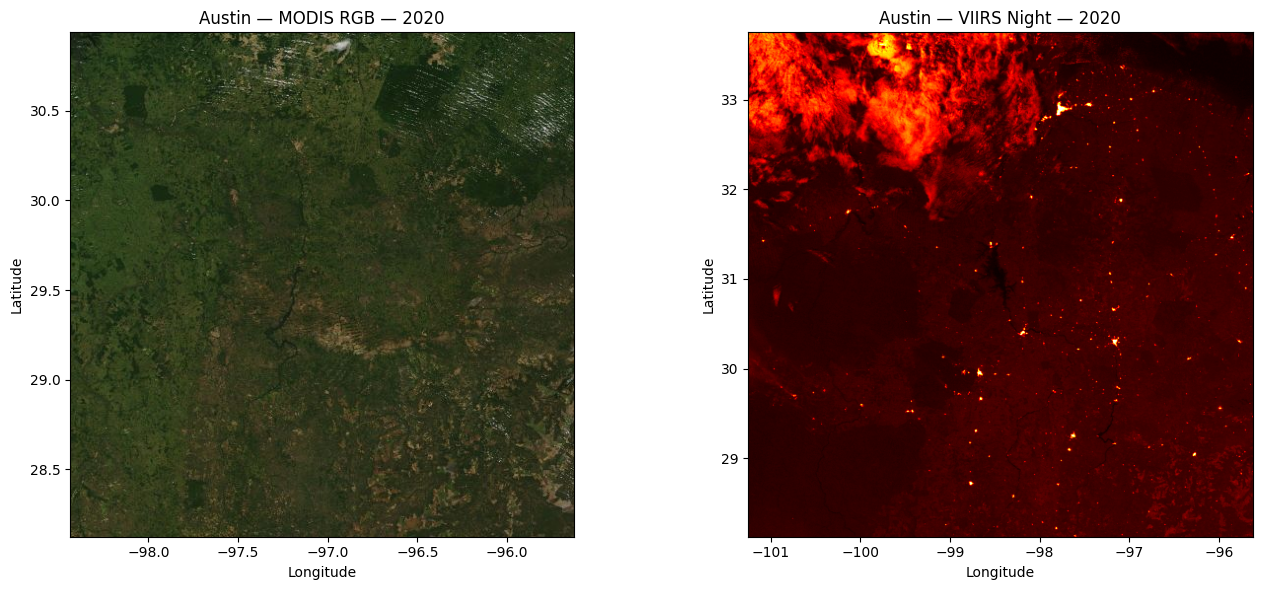

In [10]:
import matplotlib.pyplot as plt

PREVIEW_METRO = "austin"  # change to any metro
PREVIEW_YEAR  = 2020

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── MODIS RGB ────────────────────────────────────────────────────────────────
with rasterio.open(f"data/imagery/{PREVIEW_METRO}/modis_rgb/{PREVIEW_YEAR}.tif") as src:
    rgb = np.dstack([src.read(b) for b in (1, 2, 3)])
    b   = src.bounds
axes[0].imshow(rgb, extent=[b.left, b.right, b.bottom, b.top])
axes[0].set_title(f"{PREVIEW_METRO.title()} — MODIS RGB — {PREVIEW_YEAR}")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
print(f"MODIS  shape: {rgb.shape}")

# ── VIIRS Night ──────────────────────────────────────────────────────────────
with rasterio.open(f"data/imagery/{PREVIEW_METRO}/viirs_night/{PREVIEW_YEAR}.tif") as src:
    night = src.read(1)
    b     = src.bounds
axes[1].imshow(night, cmap="hot", extent=[b.left, b.right, b.bottom, b.top])
axes[1].set_title(f"{PREVIEW_METRO.title()} — VIIRS Night — {PREVIEW_YEAR}")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
print(f"VIIRS  shape: {night.shape}")

plt.tight_layout()
plt.show()

## Output Structure
```
data/imagery/
├── austin/
│   ├── modis_rgb/    2013–2023  (11 files, zoom=6, 3-band RGB)
│   └── viirs_night/  2017–2023  ( 7 files, zoom=5, 1-band grayscale)
├── dallas/ ...
├── nashville/ ...
├── phoenix/ ...
└── jacksonville/ ...
```
**Next step → `02_economic_data_downloader.ipynb`**